## Problem Statment
To analyze how flat prices vary based on area, location (zone/city), number of bathrooms, balcony availability and price per square foot, and to identify the major factors influencing property pricing.

## Objective

The objective of this project is to analyze real estate property data to understand the key factors affecting property prices such as area, location, number of bathrooms, and price per square foot. The project focuses on performing data cleaning, exploratory data analysis (EDA), and visualization to extract meaningful insights.

## Dataset Information
The dataset contains information about residential properties including:
- Name
- Property Title 
- Price
- Location
- Total_Area
- Price_per_SQFT 
- Description 
- Baths
- Balcony

### Create a DataFrame


In [2]:
import pandas as pd

df = pd.read_csv("Real Estate Data V21.csv")
df.head()

,Name,Property Title,Price,Location,Total_Area,Price_per_SQFT,Description,Baths,Balcony
0,Casagrand ECR 14,"4 BHK Flat for sale in Kanathur Reddikuppam, C...",₹1.99 Cr,"Kanathur Reddikuppam, Chennai",2583,7700,Best 4 BHK Apartment for modern-day lifestyle ...,4,Yes
1,"Ramanathan Nagar, Pozhichalur,Chennai",10 BHK Independent House for sale in Pozhichal...,₹2.25 Cr,"Ramanathan Nagar, Pozhichalur,Chennai",7000,3210,Looking for a 10 BHK Independent House for sal...,6,Yes
2,DAC Prapthi,"3 BHK Flat for sale in West Tambaram, Chennai",₹1.0 Cr,"Kasthuribai Nagar, West Tambaram,Chennai",1320,7580,"Property for sale in Tambaram, Chennai. This 3...",3,No
3,"Naveenilaya,Chepauk, Triplicane,Chennai",7 BHK Independent House for sale in Triplicane...,₹3.33 Cr,"Naveenilaya,Chepauk, Triplicane,Chennai",4250,7840,Entire Building for sale with 7 units of singl...,5,Yes
4,VGN Spring Field Phase 1,"2 BHK Flat for sale in Avadi, Chennai",₹48.0 L,"Avadi, Chennai",960,5000,"Property for sale in Avadi, Chennai. This 2 BH...",3,Yes


###  Read CSV File 


#### 1.How many features(Columns) do you have?

In [3]:
df.shape

(14528, 9)

#### 2.How many observations(rows) do you have?

In [4]:
df.shape[0]

14528

#### 3.What is the data type of each feature(Columns)?

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14528 entries, 0 to 14527
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Name            14528 non-null  object
 1   Property Title  14528 non-null  object
 2   Price           14528 non-null  object
 3   Location        14528 non-null  object
 4   Total_Area      14528 non-null  int64 
 5   Price_per_SQFT  14528 non-null  int64 
 6   Description     14528 non-null  object
 7   Baths           14528 non-null  int64 
 8   Balcony         14528 non-null  object
dtypes: int64(3), object(6)
memory usage: 1021.6+ KB


#### 4.How many missing values are there?

In [6]:

df.isnull().sum()

Name              0
Property Title    0
Price             0
Location          0
Total_Area        0
Price_per_SQFT    0
Description       0
Baths             0
Balcony           0
dtype: int64

### DATA CLEANING

In [7]:
# conver prcie column into string
df['Price'] = df['Price'].astype(str)

In [8]:
# Extract only numbers and decimal values
df['Price'] = df['Price'].str.extract('(\d+\.?\d*)')

In [9]:
# convert it into float
df['Price'] = df['Price'].astype(float)

In [10]:
df.dtypes

Name               object
Property Title     object
Price             float64
Location           object
Total_Area          int64
Price_per_SQFT      int64
Description        object
Baths               int64
Balcony            object
dtype: object

In [11]:
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.title()

In [12]:
df.columns

Index(['Name', 'Property_Title', 'Price', 'Location', 'Total_Area',
       'Price_Per_Sqft', 'Description', 'Baths', 'Balcony'],
      dtype='object')

In [13]:
# In dtaset balcony contains yes or no i converted it into yes as 1 and no as 0
df['Balcony'] = df['Balcony'].map({'Yes':1, 'No':0})

In [14]:
# remove te extra spaces in text columns
df['Name'] = df['Name'].str.strip()
df['Property_Title'] = df['Property_Title'].str.strip()
df['Location'] = df['Location'].str.strip()
df['Description'] = df['Description'].str.strip()

In [15]:
df.dtypes

Name               object
Property_Title     object
Price             float64
Location           object
Total_Area          int64
Price_Per_Sqft      int64
Description        object
Baths               int64
Balcony             int64
dtype: object

In [16]:
df.rename(columns={'Price':'Price_Lakhs'}, inplace=True) 

In [17]:
df['Location'] = df['Location'].apply(lambda x: ','.join(x.split(',')[-2:]).strip())

In [18]:
df[['Location']].head()

,Location
0,"Kanathur Reddikuppam, Chennai"
1,"Pozhichalur,Chennai"
2,"West Tambaram,Chennai"
3,"Triplicane,Chennai"
4,"Avadi, Chennai"


In [19]:
df.isnull().sum()

Name              0
Property_Title    0
Price_Lakhs       0
Location          0
Total_Area        0
Price_Per_Sqft    0
Description       0
Baths             0
Balcony           0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(8)

In [21]:
df = df.drop_duplicates()

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.columns

Index(['Name', 'Property_Title', 'Price_Lakhs', 'Location', 'Total_Area',
       'Price_Per_Sqft', 'Description', 'Baths', 'Balcony'],
      dtype='object')

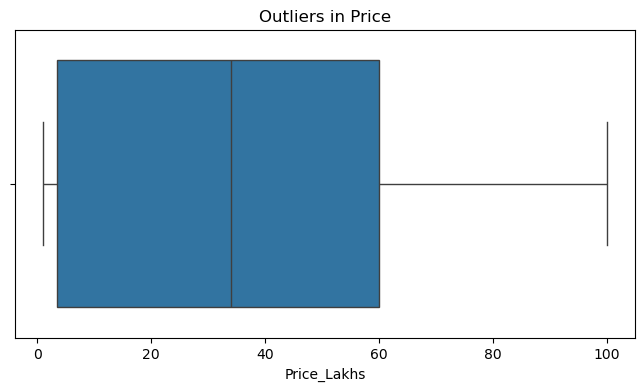

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))  
sns.boxplot(x=df['Price_Lakhs'])
plt.title("Outliers in Price")
plt.show()

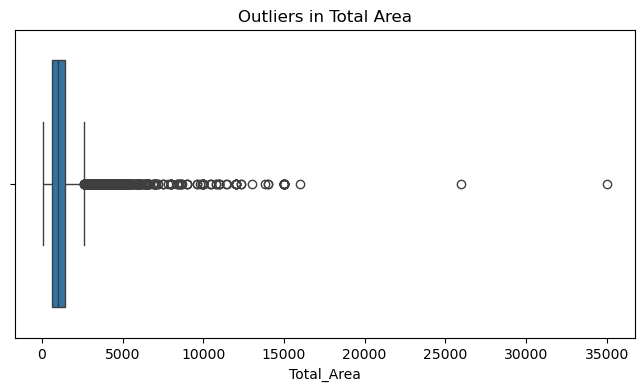

In [25]:
plt.figure(figsize=(8,4)) 
sns.boxplot(x=df['Total_Area'])
plt.title("Outliers in Total Area")
plt.show()

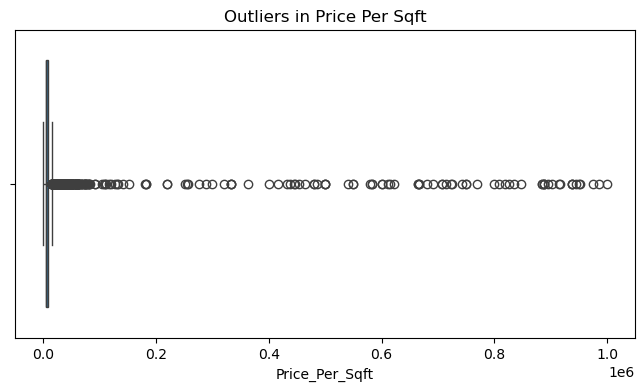

In [26]:
plt.figure(figsize=(8,4)) 
sns.boxplot(x=df['Price_Per_Sqft'])
plt.title("Outliers in Price Per Sqft")
plt.show()

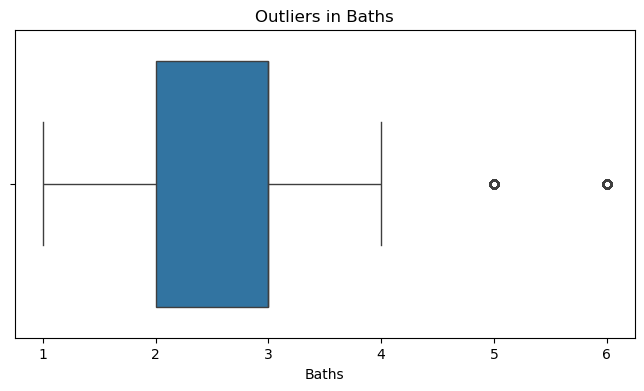

In [27]:
plt.figure(figsize=(8,4)) 
sns.boxplot(x=df['Baths'])
plt.title("Outliers in Baths")
plt.show()

#### Treating the Outliers

In [28]:
cols = ['Price_Lakhs','Total_Area','Price_Per_Sqft','Baths']

for col in cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]

In [29]:
df.shape

(11948, 9)

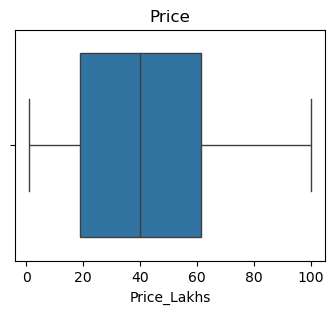

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4,3))
sns.boxplot(x=df['Price_Lakhs'])
plt.title("Price")
plt.show()

### 9. Data Analysis and Visualization (EDA)

###   Now we have Numerical columns and categorical columns 
- Categorical column -- Name, Property_Title, Location, Description
- Numerical column -- Price_Lakhs,Total_Area, Price_Per_Sqft, Baths, Balcony

### UNIVARIATE ANALYSIS
A) Numerical Variables

### 1. Central Tendency & Dispersion

In [31]:
df[['Price_Lakhs','Total_Area','Price_Per_Sqft','Baths','Balcony']].describe()

,Price_Lakhs,Total_Area,Price_Per_Sqft,Baths,Balcony
count,11948.000000,11948.000000,11948.000000,11948.000000,11948.000000
mean,40.587018,1036.834282,6468.842484,2.651322,0.552645
std,27.690279,501.548803,2991.031217,0.678713,0.497242
min,1.000000,100.000000,0.000000,1.000000,0.000000
25%,19.000000,650.000000,4360.000000,2.000000,0.000000
50%,40.000000,970.000000,5690.000000,3.000000,1.000000
75%,61.500000,1261.000000,7870.000000,3.000000,1.000000
max,99.990000,2620.000000,16250.000000,4.000000,1.000000


### 2. Histogram (Price_Lakhs)

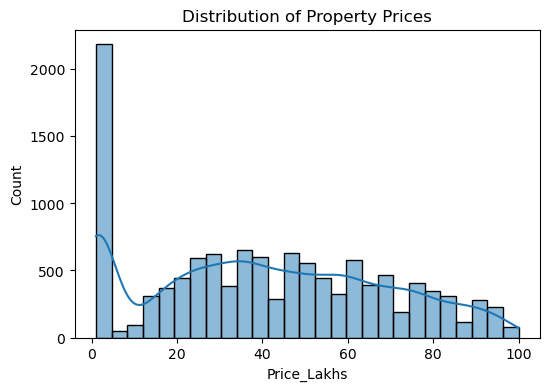

In [32]:
plt.figure(figsize=(6,4))
sns.histplot(df['Price_Lakhs'], kde=True)
plt.title("Distribution of Property Prices")
plt.show()

### Histogram (Total_Area)

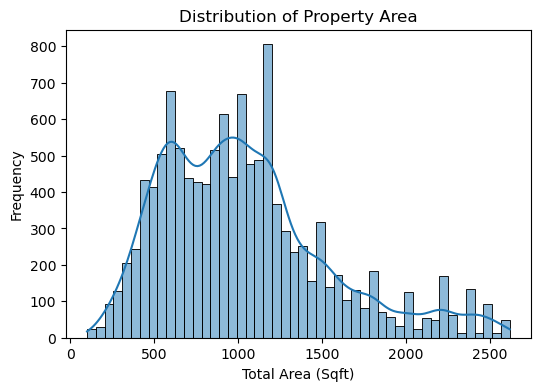

In [33]:
plt.figure(figsize=(6,4))
sns.histplot(df['Total_Area'], kde=True)
plt.title("Distribution of Property Area")
plt.xlabel("Total Area (Sqft)")
plt.ylabel("Frequency")
plt.show()

### 3. Boxplot (Outlier Detection)

#### Price Boxplot

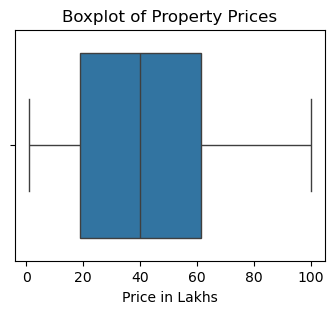

In [34]:
plt.figure(figsize=(4,3))
sns.boxplot(x=df['Price_Lakhs'])
plt.title("Boxplot of Property Prices")
plt.xlabel("Price in Lakhs")
plt.show()

#### Total Area Boxplot

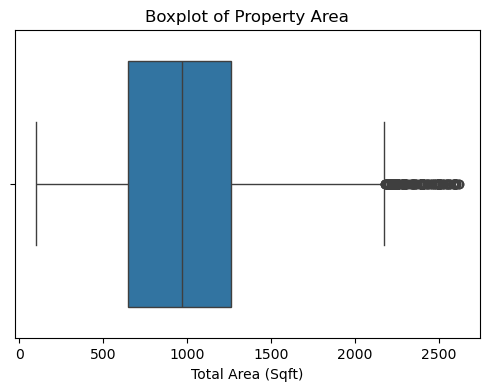

In [35]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Total_Area'])
plt.title("Boxplot of Property Area")
plt.xlabel("Total Area (Sqft)")
plt.show()

### 4. Violin Plot

##### This Shows distribution + density

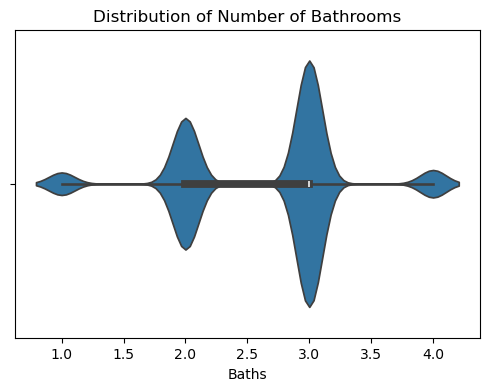

In [36]:
plt.figure(figsize=(6,4))
sns.violinplot(x=df['Baths'])
plt.title("Distribution of Number of Bathrooms")
plt.show()

### B) Categorical Variables

### 1.Count Plot 

#### Location Distribution

In [37]:
df['Location'].value_counts().head(10) # This shows the top 10 locations with the highest number of properties

Location
Electronic City,Bangalore    87
Mira Road East,Mumbai        83
Hadapsar,Pune                82
Pimpri,Pune                  60
Whitefield,Bangalore         57
JP Nagar,Bangalore           52
Dhayari,Pune                 52
Banashankari,Bangalore       51
Chandapura,Bangalore         50
Chakan, Pune                 50
Name: count, dtype: int64

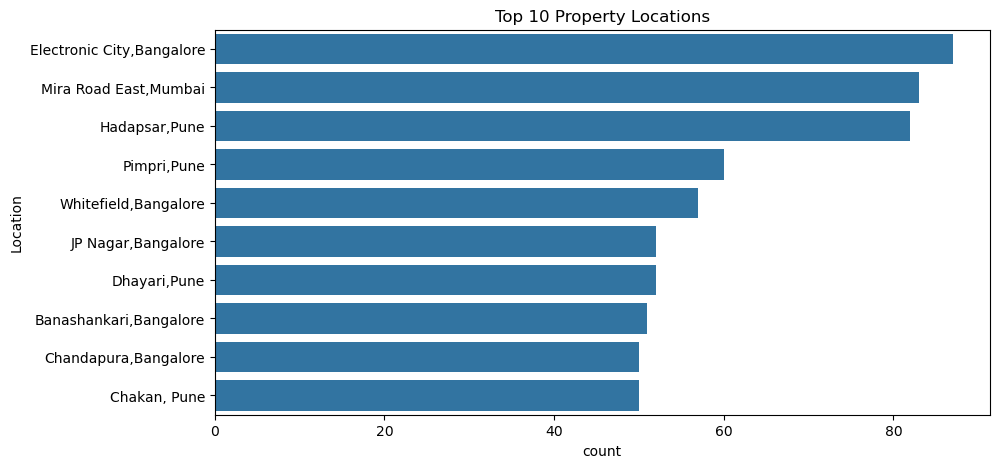

In [38]:
plt.figure(figsize=(10,5))
sns.countplot(y='Location', data=df,
              order=df['Location'].value_counts().index[:10])
plt.title("Top 10 Property Locations")
plt.show()

### 2. Pie Chart

#### Balcony Availability

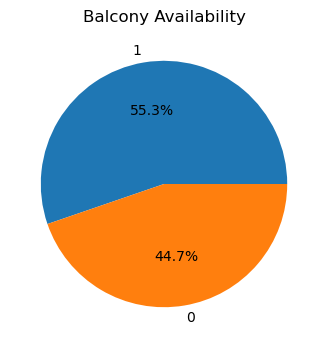

In [39]:
df['Balcony'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(4,4))
plt.title("Balcony Availability")
plt.ylabel('')
plt.show()

### BIVARIATE ANALYSIS
Analyze relationship between two variables

### 1.Continuous vs Continuous

#### Price vs Total Area

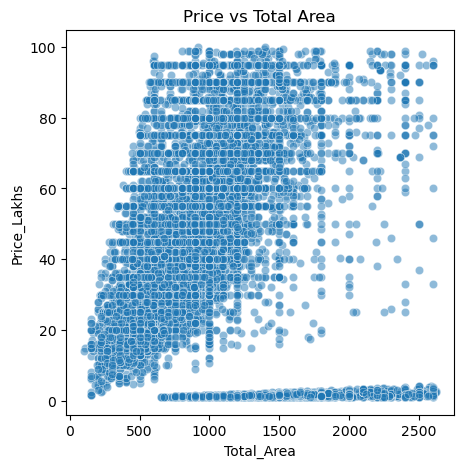

In [40]:
plt.figure(figsize=(5,5))
sns.scatterplot(x='Total_Area', y='Price_Lakhs', data=df, alpha=0.5)
plt.title("Price vs Total Area")
plt.show()

#### Correlation Heatmap

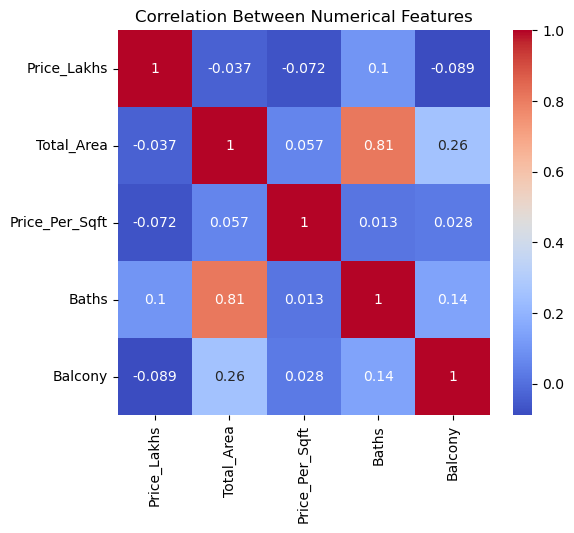

In [41]:
plt.figure(figsize=(6,5))
sns.heatmap(df[['Price_Lakhs','Total_Area','Price_Per_Sqft','Baths','Balcony']].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Between Numerical Features")
plt.show()

### 2.Continuous vs Categorical

#### Average Price by Location (Groupby)

In [42]:
df.groupby('Location')['Price_Lakhs'].mean().sort_values(ascending=False).head(10)

Location
Vallakkottai, Chennai              99.0
Badesahebguda,Hyderabad            96.0
Vinod Nagar West,New Delhi         95.0
Dharamveer Nagar, Mumbai           95.0
Ashok Nagar,New Delhi              95.0
Parel,Mumbai                       95.0
Madhavaram Milk Colony, Chennai    95.0
Sector 1 Dwarka,New Delhi          95.0
Vengadamangalam, Chennai           95.0
Chamrajpet,Bangalore               95.0
Name: Price_Lakhs, dtype: float64

#### Pivot Table (Price by Baths)

In [43]:
pd.pivot_table(df,
               values='Price_Lakhs',
               index='Baths',
               aggfunc='mean')

,Price_Lakhs
Baths,
1,22.882464
2,36.354107
3,46.702916
4,20.504269


Shows average price based on number of bathrooms.

### Categorical vs Categorical 

#### Baths vs Balcony(Crosstab)

In [44]:
pd.crosstab(df['Baths'], df['Balcony'])

Balcony,0,1
Baths,,
1,312,317
2,1840,1834
3,3170,3709
4,23,743


## Key Insights
- Property price increases with area size.
- Location plays a major role in determining price.
- Properties with more bathrooms and balconies tend to have higher prices.
- Price per square foot varies significantly across locations.

## Business Recommendations
- Investors should focus on locations with higher price per square foot growth.
- Larger properties tend to generate higher total value in the real estate market.
- Properties with additional amenities such as balconies and bathrooms show higher price trends.

## Conclusion

- This analysis highlights how property size, location, and amenities influence real estate pricing.
-  The project demonstrates how data cleaning, exploratory data analysis, and visualization techniques can be used to extract valuable insights from real estate data.